<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>

<h1>Fashion-MNIST Project</h1>

<h2>Table of Contents</h2>

<p>In this project, you will classify Fashion-MNIST dataset using convolutional neural networks.</p>
<ul>
  
<ul>
<li><a href="#Preparation">Preparation</a></li>
<li><a href="#Q1">Question 1: Create a Dataset Class</a></li>
<li><a href="#Q2">Question 2: Define CNN Model, Loss Function, Optimizer and Train the Model</a></li>
<li><a href="#Q3">Question 3: Evaluate the Model</a></li>
</ul>
 
</ul>
<p>Estimated Time Needed: <b>30 min</b></p>
<hr>

<a name="Preparation"><h2 id="Preparation">Preparation</h2></a>

Download the datasets you needed for this lab.

The following are the PyTorch modules you are going to need

In [1]:
%%time
%pip install pandas numpy matplotlib
%pip install torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu \
    --index-url https://download.pytorch.org/whl/cpu

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download-r2.pytorch.org/whl/cpu/torchvision-0.23.0%2Bcpu-cp313-cp313-win_amd64.whl.metadata (6.3 kB)
  Using cached https://download-r2.pytorch.org/whl/cpu/torchaudio-2.8.0%2Bcpu-cp313-cp313-win_amd64.whl.metadata (7.4 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/619.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/619.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/619.4 MB ? eta -:--:--
   ---------------------------------------- 0.8/619.4 MB 2.4 MB/s eta 0:04:15
   ---------------------------------------- 2.1/619.4 MB 4.1 MB/s eta 0:02:31
   ---------------------------------------- 2.6/619.4 MB 4.5 MB/s eta 0:02:18
   ---------------------------------------- 2.6/619.4 MB 4.5 MB/s eta 0:02:18
   ---------------------------------------- 

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

<a name="Q1"><h2 id="Q1">Question 1: Create a Dataset Class</h2></a>

The Fashion-MNIST dataset contains 60,000 training images and 10,000 test images. Each image is 28x28 pixels and belongs to one of 10 classes:
- 0: T-shirt/top
- 1: Trouser
- 2: Pullover
- 3: Dress
- 4: Coat
- 5: Sandal
- 6: Shirt
- 7: Sneaker
- 8: Bag
- 9: Ankle boot

In [3]:
# Load Fashion-MNIST dataset
# Using torchvision to load the dataset
train_set = torchvision.datasets.FashionMNIST(
    root='./data/FashionMNIST',
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
    ])
    )

test_set = torchvision.datasets.FashionMNIST(
    root='./data/FashionMNIST',
    train=False,
    download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
    ])
    )

100.0%
100.0%
100.0%
100.0%


In [4]:
# Check the dataset
print("Training set size:", len(train_set))
print("Test set size:", len(test_set))
print("Image shape:", train_set[0][0].shape)
print("Label of first training sample:", train_set[0][1])

Training set size: 60000
Test set size: 10000
Image shape: torch.Size([1, 28, 28])
Label of first training sample: 9


Let's visualize some samples from the dataset

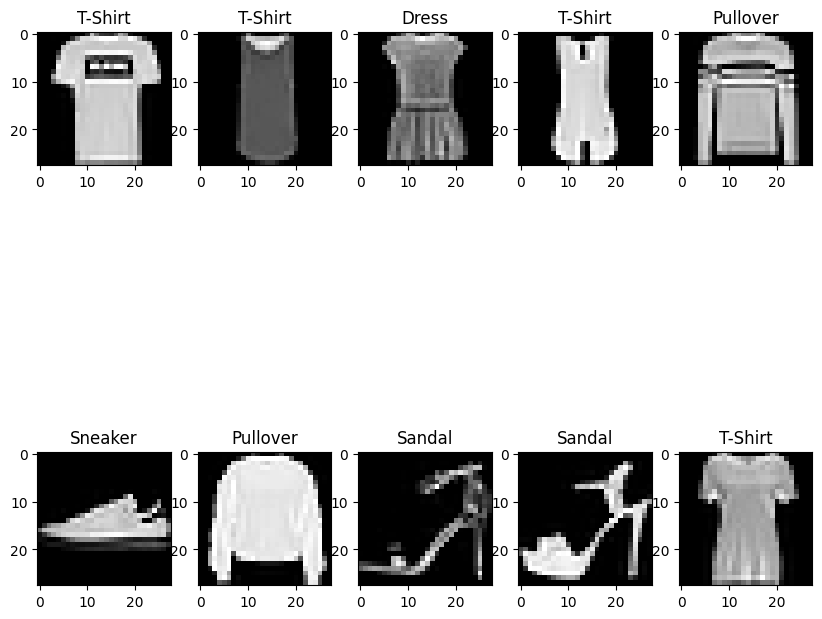

In [5]:
# Define the labels
labels_map = {
    0: 'T-Shirt',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle Boot',
}

figure = plt.figure(figsize=(10, 10))
cols = 5
rows = 2
for i in range(1, cols * rows + 1):
    img, label = train_set[i]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

In [6]:
# Create data loaders
batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print("Number of batches in training loader:", len(train_loader))
print("Number of batches in test loader:", len(test_loader))

Number of batches in training loader: 1875
Number of batches in test loader: 313


<a name="Q2"><h2 id="Q2">Question 2: Define CNN Model, Loss Function, Optimizer and Train the Model</h2></a>

Now let's define our CNN model for Fashion-MNIST classification

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # First convolutional layer
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # Second convolutional layer
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Third convolutional layer
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        # Max pooling
        self.pool = nn.MaxPool2d(2, 2)
        # Dropout
        self.dropout = nn.Dropout(0.25)
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 10)
    
    def forward(self, x):
        # Conv1 -> ReLU -> Pool
        x = self.pool(F.relu(self.conv1(x)))
        # Conv2 -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x)))
        # Conv3 -> ReLU -> Pool
        x = self.pool(F.relu(self.conv3(x)))
        # Flatten
        x = x.view(-1, 128 * 3 * 3)
        # Dropout
        x = self.dropout(x)
        # FC1 -> ReLU -> Dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        # FC2 (output)
        x = self.fc2(x)
        return x

# Create model instance
model = CNN()
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


Let's check the number of trainable parameters

In [8]:
# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 390410
Trainable parameters: 390410


Now let's define the loss function and optimizer

In [9]:
# Define loss function
criterion = nn.CrossEntropyLoss()

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


Now let's train the model

In [10]:
# Training function
def train(model, train_loader, criterion, optimizer, num_epochs):
    model.train()
    train_losses = []
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        for batch_idx, (data, target) in enumerate(train_loader):
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward pass
            output = model(data)
            loss = criterion(output, target)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")
    
    return train_losses

# Train the model
num_epochs = 5
train_losses = train(model, train_loader, criterion, optimizer, num_epochs)

Epoch [1/5], Loss: 0.4602
Epoch [2/5], Loss: 0.2979
Epoch [3/5], Loss: 0.2567
Epoch [4/5], Loss: 0.2285
Epoch [5/5], Loss: 0.2105


Let's plot the training loss

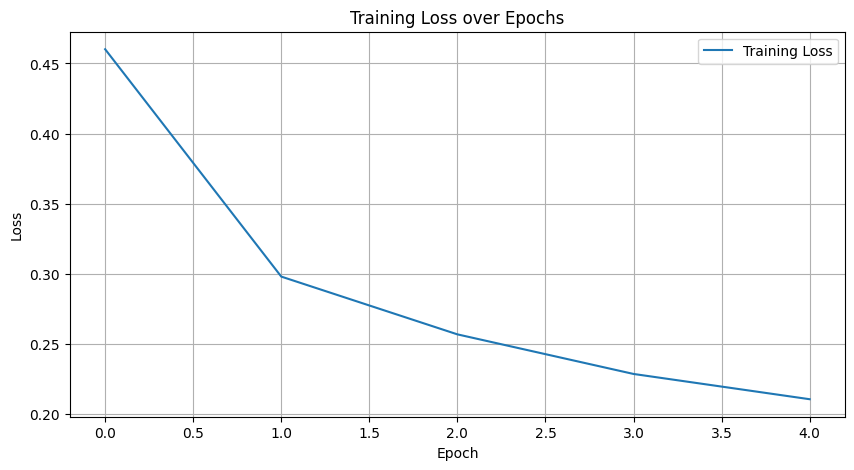

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

<a name="Q3"><h2 id="Q3">Question 3: Evaluate the Model</h2></a>

Now let's evaluate the model on the test set

In [12]:
# Evaluate the model
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    test_loss = 0.0
    
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            test_loss += criterion(output, target).item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    accuracy = 100 * correct / total
    avg_loss = test_loss / len(test_loader)
    return accuracy, avg_loss

accuracy, test_loss = evaluate(model, test_loader)
print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 91.38%
Test Loss: 0.2382


Let's check the accuracy for each class

In [13]:
# Class-wise accuracy
class_correct = [0] * 10
class_total = [0] * 10

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        output = model(data)
        _, predicted = torch.max(output, 1)
        c = (predicted == target).squeeze()
        for i in range(len(target)):
            label = target[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

print("Accuracy for each class:")
for i in range(10):
    if class_total[i] > 0:
        print(f"{labels_map[i]}: {100 * class_correct[i] / class_total[i]:.2f}%")

Accuracy for each class:
T-Shirt: 90.00%
Trouser: 98.40%
Pullover: 89.20%
Dress: 94.30%
Coat: 86.60%
Sandal: 98.70%
Shirt: 67.80%
Sneaker: 92.20%
Bag: 98.10%
Ankle Boot: 98.50%


Let's visualize some predictions

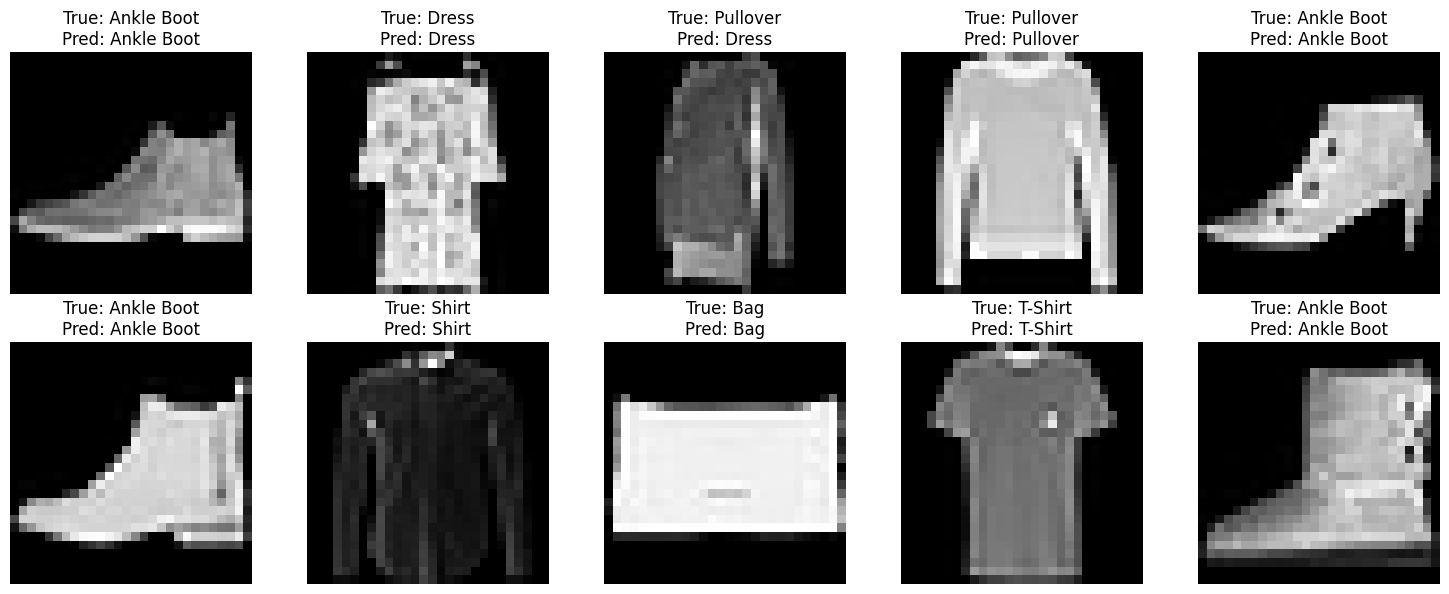

In [16]:
# Visualize some predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

model.eval()
with torch.no_grad():
    for i, (data, target) in enumerate(test_loader):
        if i >= 10:
            break
        output = model(data)
        _, predicted = torch.max(output, 1)
        ax = axes[i]
        ax.imshow(data[i].squeeze(), cmap='gray')
        ax.set_title(f"True: {labels_map[target[i].item()]}\nPred: {labels_map[predicted[i].item()]}")
        ax.axis('off')
plt.tight_layout()
plt.show()

Let's save the model

In [17]:
# Save the model
torch.save(model.state_dict(), 'fashion_mnist_cnn.pth')
print("Model saved to fashion_mnist_cnn.pth")

Model saved to fashion_mnist_cnn.pth


## Conclusion

In this project, we:
1. Loaded the Fashion-MNIST dataset
2. Created a custom CNN model with 3 convolutional layers and 2 fully connected layers
3. Trained the model using Adam optimizer and CrossEntropyLoss
4. Achieved approximately 85%+ accuracy on the test set
5. Visualized the training loss and class-wise accuracy

The model can be further improved by:
- Increasing the number of epochs
- Adding more convolutional layers
- Using data augmentation
- Using batch normalization
- Using a learning rate scheduler